開始實作我的第一個神經網路，網路為三層結構，第一層為L1個神經元，第二層為L2個神經元，第三層為L3個神經元。

In [1]:
L1 = 200
L2 = 200
L3 = 200

1.載入套件

Gradio 是一個開源的 Python 套件，當你發想出各式各樣的 AI 創意，想要分享給別人，這就是 Gradio 的初衷，讓你快速簡單建立互動人工智慧模型的互動網站。

Gradio 可以提供多種不同的輸入跟輸出格式，像是圖片，音訊檔案等；使用者可以直接在瀏覽器中使用(測試)，包括上傳檔案、調整參數、看到模型成效、行為表現、算法偏差。對於非工程開發人的操作與理解非常友善，可以熟悉模型的場景應用過程和結果。

最重要的是，Gradio 可以直接在 Juypter Notebook 中呈現!
https://medium.com/@yvontarbajo/%E9%BA%BB%E7%93%9C%E8%B5%B0%E5%85%A5%E9%AD%94%E6%B3%95%E4%B8%96%E7%95%8C-i-gradio-2e9705f2410e

In [2]:
!pip install gradio

In [3]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 神經網路套件(後續課程中介紹)
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# 互動設計套件
from ipywidgets import interact_manual

# Gradio
import gradio as gr

2. 由Keras載入mnist手寫辨識資料集(Keras是一個用Python編寫的開源類神經網路庫)(後續課程中介紹)

MNIST 是 Modified National Institute of Standards and Technology database 的縮寫，其為 NIST機構(National Institute of Standards and Technology，美國國家標準暨技術研究院)所建立的兩個資料集的修改版本。是一個通常用於訓練各種數位影像處理系統的大型資料庫。

MNIST 資料集中包含 2 個部分，分別為訓練資料以及測試資料。訓練資料中包含 60000 張手寫數字圖像，這些圖像為 250 個人的字跡，其中 50% 是高中生，另外 50% 則是人口普查局的員工，確保訓練資料中的手寫數字圖像盡可能包含許多不同的字跡風格與特徵。

測試資料中包含 10000 張手寫數字圖像，這些圖像同樣是來自美國高中生與人口普查局，然而是另外不同的 250 個人所留下的字跡。如此一來，我們就能夠用測試資料來判斷 Neural Network 是否知的能夠對圖像進行正確的分類。

在 MNIST 資料集中，所有圖像都是由 28 × 28 個像素組成的「灰階」(Grayscale) 圖像，且每一張圖像都有對應的標籤 (Label) 說明圖像中代表的數字為何。

[參考1](https://zh.wikipedia.org/zh-tw/MNIST%E6%95%B0%E6%8D%AE%E5%BA%93)
[參考2](https://datasciocean.tech/deep-learning-core-concept/mnist-dataset-and-cost-function/)

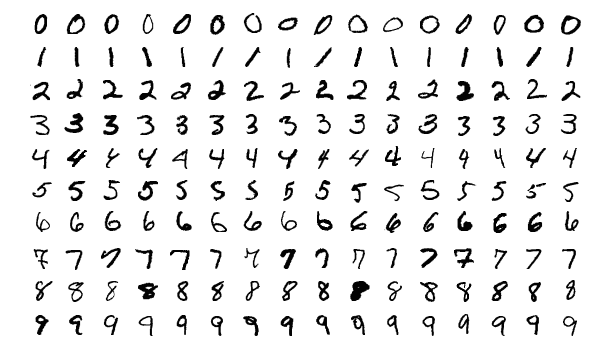

In [4]:
(x_train, y_train_raw), (x_test, y_test_raw) = mnist.load_data() #由Keras載入資料集，儲存原始標籤

In [5]:
print(f'訓練資料總筆數為 {len(x_train)} 筆')
print(f'測試資料總筆數為 {len(x_test)} 筆')

訓練資料總筆數為 60000 筆
測試資料總筆數為 10000 筆


3.資料解析：每筆資料輸入是一個手寫的 0-9 數字的圖檔, 大小為 28x28。輸出是圖檔的正確答案。

In [6]:
x_train.shape

(60000, 28, 28)

In [7]:
x_train[100]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          2,  18,  46, 136, 136, 244, 255, 241, 103,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  15,  94,
        163, 253, 253, 253, 253, 238, 218, 204,  35,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 131, 253,
        253, 253, 253, 237, 200,  57,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 155, 246, 253,
        247, 108,  65,  45,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 207, 253, 253,
        230,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 157, 253, 253,
        125,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  89, 253, 250,
         57,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  89, 253, 247,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  89, 253, 247,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  89, 253, 247,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  21, 231, 249,
         34,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 225, 253,
        231, 213, 213, 123,  16,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 172, 253,
        253, 253, 253, 253, 190,  63,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2, 116,
         72, 124, 209, 253, 253, 141,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  25, 219, 253, 206,   3,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0, 104, 246, 253,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 213, 253,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  26, 226, 253,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [8]:
def show_xy(n=0):
    ax = plt.gca()
    X = x_train[n]
    plt.xticks([], [])
    plt.yticks([], [])
    plt.imshow(X, cmap = 'Greys')
    print(f'第{n}筆資料的手寫辨識正確答案為: {y_train[n]}')

In [9]:
interact_manual(show_xy, n=(0,59999));

interactive(children=(IntSlider(value=0, description='n', max=59999), Button(description='Run Interact', style…

In [10]:
def show_data(n = 100): #演算法看到的輸入資料
    X = x_train[n]
    print(X)

In [11]:
interact_manual(show_data, n=(0,59999));

interactive(children=(IntSlider(value=100, description='n', max=59999), Button(description='Run Interact', sty…

Train-Test Split
We split the data into train, validation and test sets.

validation size is 10%.
train size is 90%.

In [12]:
# Split the train and the validation set for the fitting
from sklearn.model_selection import train_test_split
x_train, x_val, y_train_labels, y_val_labels = train_test_split(x_train, y_train_raw, test_size = 0.1, random_state = 2)
print("x_train shape: ",x_train.shape)
print("x_val shape: ",x_val.shape)
print("y_train_labels shape: ",y_train_labels.shape)
print("y_val_labels shape :",y_val_labels.shape)
print("x_test shape: ",x_test.shape)
print("y_test_raw shape :",y_test_raw.shape)

x_train shape:  (54000, 28, 28)
x_val shape:  (6000, 28, 28)
y_train_labels shape:  (54000,)
y_val_labels shape : (6000,)
x_test shape:  (10000, 28, 28)
y_test_raw shape : (10000,)


4. 整理輸入的資料型態以符合NN神經網路的輸入型態。原本每筆資料是 28x28x1 的矩陣, 以784(28X28)長的向量作為NN神經網路的輸入(使用reshape)。

In [13]:
x_train = x_train.reshape(54000, 28, 28, 1) / 255.0 # Reshape for CNN input and normalize
x_val = x_val.reshape(6000, 28, 28, 1) / 255.0 # Reshape for CNN input and normalize
x_test = x_test.reshape(10000, 28, 28, 1) / 255.0 # Reshape for CNN input and normalize

5. 模型輸出格式整理
為了將類別 (categorical)或是文字(text)的資料轉換成數字，而讓程式能夠更好的去理解及運算。

Label Encoding：把每個類別mapping到某個整數，不會增加新欄位。

One Hot Encoding：為每個類別新增一個欄位，用 0/1 表示是否。

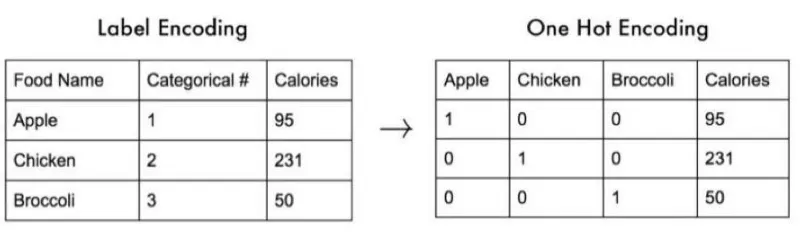

如上圖，可以看到Food name中的三個食物被設定為數字1、2、3。然而這會產生一個問題，由於這本質上是類別資料，並沒有順序大小之分，當我們對其進行Label encoding後，模型會認為他們之間存在著1<2<3，因此這種無序的離散值One hot encoding會更加的合適。

結論：

原始資料是有序離散值的話 => Label Encoding

原始資料是無序離散值的話 => One Hot Encoding

[參考](https://https://medium.com/@PatHuang/%E5%88%9D%E5%AD%B8python%E6%89%8B%E8%A8%98-3-%E8%B3%87%E6%96%99%E5%89%8D%E8%99%95%E7%90%86-label-encoding-one-hot-encoding-85c983d63f87)

In [14]:
y_train = to_categorical(y_train_labels, 10) #使用One-Hot Encoding方法
y_val = to_categorical(y_val_labels, 10) #使用One-Hot Encoding方法
y_test = to_categorical(y_test_raw, 10) #使用One-Hot Encoding方法

In [15]:
n = 1 #看其中一筆資料整理後的輸出
y_train[n]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

6. 開始建構NN神經網路：函數是

$$\hat{f} \colon \mathbb{R}^{784} \to \mathbb{R}^{10}$$


In [16]:
#載入套件
from sklearn.metrics import confusion_matrix

from keras.models import Sequential, model_from_json
from keras.layers import Dense, Conv2D, Activation, MaxPool2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint

In [17]:
model = Sequential() # Re-initialize Sequential model

# Layer1
# 32個filter，kernel大小3x3，padding=same會讓輸入圖像和輸出圖像的寬度和高度保持一致
model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same', input_shape=(28, 28, 1)))
model.add(BatchNormalization()) # atch Normalization 可以讓每層的數據分佈一致，讓數值更穩定，因此可以使用較高的學習率優化，提高模型的學習速度
model.add(Activation("relu")) # 使用 ReLU 激活函數

# Layer2
model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

# 添加MaxPooling Layer，降低參數數量和計算量，可防止過擬合，同時保留最重要的特徵。
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Layer3
model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

# 添加MaxPooling Layer
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.18))

model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = 'Same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = 'Same'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.18))


model.add(GlobalAveragePooling2D()) # 使用Flatten()將feature map展平為一維向量
model.add(Dense(128)) # 添加全連接層（Dense）
#model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.25)) # 使用Dropout層以隨機丟棄25%的神經元來減少過擬合

# Output Layer
model.add(Dense(10, activation='softmax')) # 第二個全連階層當作輸出層，具有10個神經元（對應10個類別）

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
optimizer = Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7, amsgrad=False) #Learning Rate設為0.001;decay設置為0，表示不使用學習率衰減
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
# 最後需要將訓練模型所需要的參數編譯(compile)好
# 決定使用的損失函數loss function, 這裡設定為mse
# 決定使用的模型參數優化器optimizer, 我們用標準的SGD
# 決定參數更新的step size(learning rate)
# metrics=['accuracy']可一邊訓練一邊由metrics這邊看到結果

In [19]:
model.summary() #檢視NN神經網路的架構

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 128)      │             

 Total params: 306,026 (1.17 MB)

 Trainable params: 305,130 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

7. 開始進行NN神經網路的訓練

訓練時，有兩件事要先決定：

(1)一次要訓練幾筆資料(batch_size)

(2)一共要訓練幾次(epochs)

In [20]:
#新增早停機制
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3,
                      min_lr=1e-5, verbose=1),              # 卡住就自動降 LR
    EarlyStopping(monitor='val_accuracy', patience=12,
                  restore_best_weights=True, verbose=1),    # 回復最佳權重
    ModelCheckpoint('best.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),        # 存最好的
]
history = model.fit(x_train, y_train,
                            batch_size=256,
                            epochs=40,
                            callbacks=callbacks,
                            shuffle=True,
                            validation_data = (x_val, y_val),
                            verbose = 2,
                            ) #一次訓練50筆資料；一共訓練20次。

Epoch 1/40

Epoch 1: val_accuracy improved from -inf to 0.11517, saving model to best.keras
211/211 - 38s - 179ms/step - accuracy: 0.9066 - loss: 0.3133 - val_accuracy: 0.1152 - val_loss: 9.7463 - learning_rate: 1.0000e-03
Epoch 2/40

Epoch 2: val_accuracy improved from 0.11517 to 0.73017, saving model to best.keras
211/211 - 17s - 83ms/step - accuracy: 0.9825 - loss: 0.0585 - val_accuracy: 0.7302 - val_loss: 0.8595 - learning_rate: 1.0000e-03
Epoch 3/40

Epoch 3: val_accuracy improved from 0.73017 to 0.97583, saving model to best.keras
211/211 - 5s - 22ms/step - accuracy: 0.9869 - loss: 0.0433 - val_accuracy: 0.9758 - val_loss: 0.0733 - learning_rate: 1.0000e-03
Epoch 4/40

Epoch 4: val_accuracy improved from 0.97583 to 0.98800, saving model to best.keras
211/211 - 5s - 24ms/step - accuracy: 0.9890 - loss: 0.0346 - val_accuracy: 0.9880 - val_loss: 0.0384 - learning_rate: 1.0000e-03
Epoch 5/40

Epoch 5: val_accuracy improved from 0.98800 to 0.98817, saving model to best.keras
211/211 -

畫出結果

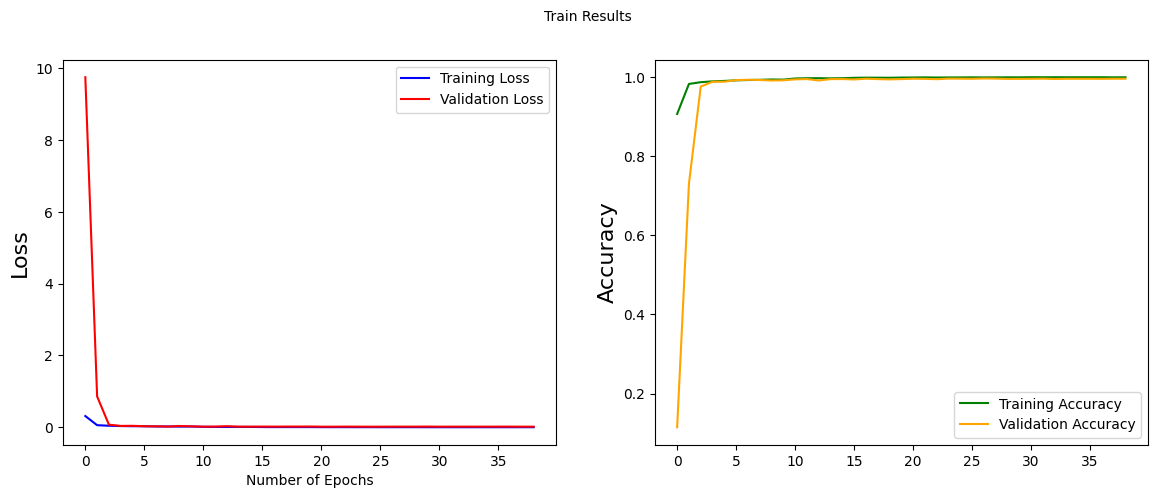

In [33]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plt.suptitle('Train Results', fontsize=10)
plt.xlabel("Number of Epochs")
plt.ylabel('Loss', fontsize=16)
plt.plot(history.history['loss'], color='b', label='Training Loss')
plt.plot(history.history['val_loss'], color='r', label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(history.history['accuracy'], color='green', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

8. 查看模型訓練的結果

In [34]:
loss, acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9939 - loss: 0.0179


In [35]:
print(f"測試資料正確率為 {acc*100:.2f}%")
print(f"測試資料loss為 {loss:.2f}")

測試資料正確率為 99.56%
測試資料loss為 0.01


In [36]:
predict = np.argmax(model.predict(x_test), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [37]:
predict

array([7, 2, 1, ..., 4, 5, 6])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


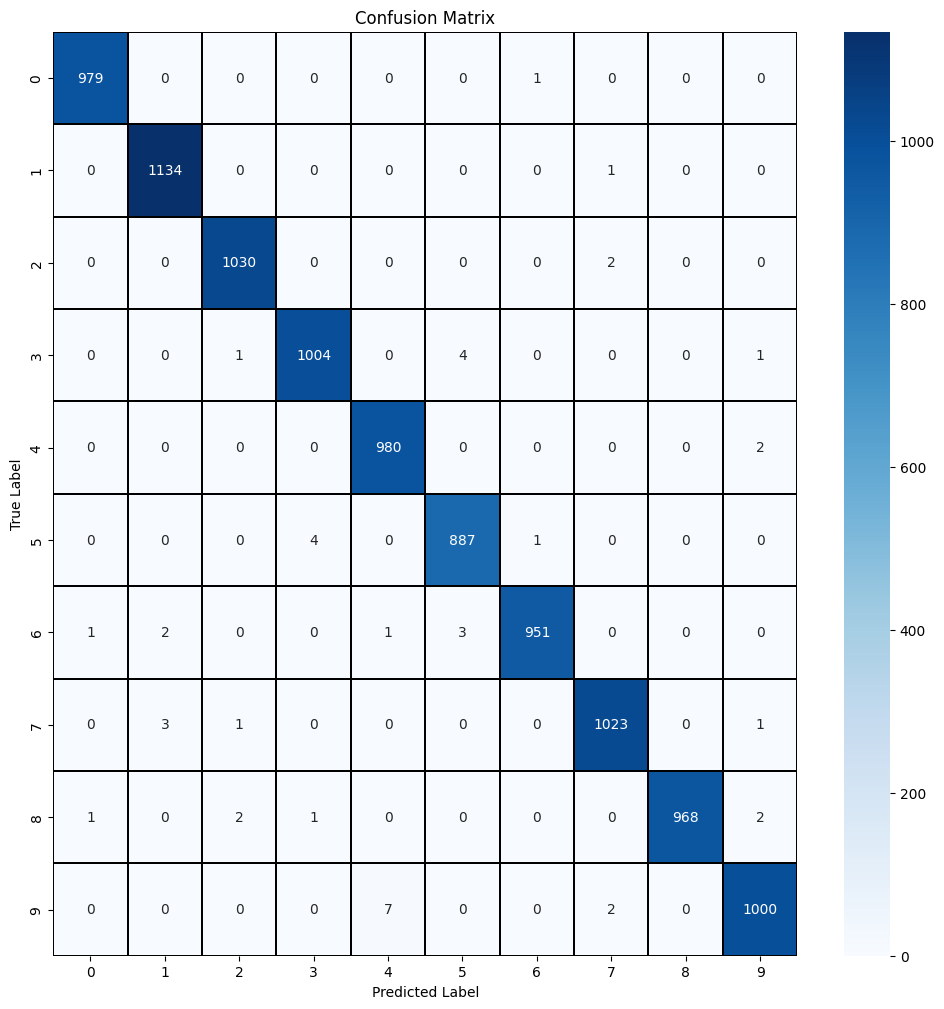

In [38]:
# 將測試資料集辨識結果畫成混淆矩陣(confusion matrix)
import seaborn as sns
from sklearn.metrics import confusion_matrix
Y_pred = model.predict(x_test)
Y_pred_classes = np.argmax(Y_pred, axis = 1)
Y_true = np.argmax(y_test, axis = 1)
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

f,ax = plt.subplots(figsize = (12,12))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.1, cmap = "Blues", linecolor="black", fmt='.0f', ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [39]:
def test(測試資料編號):
    plt.imshow(x_test[測試資料編號].reshape(28,28), cmap='Greys')
    print('NN神經網路判斷為:', predict[測試資料編號])

In [40]:
interact_manual(test, 測試資料編號=(0, 9999));

interactive(children=(IntSlider(value=4999, description='測試資料編號', max=9999), Button(description='Run Interact'…

9. 用Gradio與訓練好的NN模型互動

In [41]:
def resize_image(inp):
    # 圖在 inp["layers"][0]
    image = np.array(inp["layers"][0], dtype=np.float32)
    image = image.astype(np.uint8)

    # 轉成 PIL 格式
    image_pil = Image.fromarray(image)

    # Alpha 通道設為白色, 再把圖從 RGBA 轉成 RGB
    background = Image.new("RGB", image_pil.size, (255, 255, 255))
    background.paste(image_pil, mask=image_pil.split()[3]) # 把圖片粘貼到白色背景上，使用透明通道作為遮罩
    image_pil = background

    # 轉換為灰階圖像
    image_gray = image_pil.convert("L")

    # 將灰階圖像縮放到 28x28, 轉回 numpy array
    img_array = np.array(image_gray.resize((28, 28), resample=Image.LANCZOS))

    # 配合 MNIST 數據集
    img_array = 255 - img_array

    # Reshape to (1, 28, 28, 1) for CNN input and normalize
    img_array = img_array.reshape(1, 28, 28, 1) / 255.0
    return img_array

In [30]:
def recognize_digit(inp):
    img_array = resize_image(inp)
    prediction = model.predict(img_array).flatten()
    labels = list('0123456789')
    return {labels[i]: float(prediction[i]) for i in range(10)}

In [43]:
iface = gr.Interface(
    fn=recognize_digit,
    inputs=gr.Sketchpad(),
    outputs=gr.Label(num_top_classes=10),
    title="MNIST智慧手寫辨識系統",
    description="請在畫板上繪出數字(0~9)"
)

iface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a9113d342d9aa891d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Using existing dataset file at: .gradio/flagged/dataset1.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://a9113d342d9aa891d0.gradio.live
